In [1]:
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'], check=True)

import os, shutil, yaml, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

print('Ultralytics YOLO san sang!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics YOLO san sang!


In [2]:
BASE       = Path('/kaggle/input/datasets/giahuy038/doanai/archive')
DATA_IMGS  = BASE / 'data_images'
DATA_LBLS  = BASE / 'data_label'
SPLIT_DIR  = BASE / 'split_dataset'
WORK_DIR   = Path('/kaggle/working/dataset')

with open(BASE / 'classes_en.txt') as f:
    classes = [line.strip() for line in f if line.strip()]

with open(SPLIT_DIR / 'train_files.txt') as f:
    train_list = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / 'valid_files.txt') as f:
    valid_list = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / 'test_files.txt') as f:
    test_list = [l.strip() for l in f if l.strip()]

print(f'So class : {len(classes)}')
print(f'Train    : {len(train_list)} anh')
print(f'Val      : {len(valid_list)} anh')
print(f'Test     : {len(test_list)} anh')
print(f'Tong     : {len(train_list)+len(valid_list)+len(test_list)} anh')

So class : 67
Train    : 5396 anh
Val      : 675 anh
Test     : 675 anh
Tong     : 6746 anh


In [3]:
from tqdm import tqdm

# Tạo thư mục
for split in ['train', 'val', 'test']:
    (WORK_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (WORK_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

def copy_files(file_list, split_name):
    count = 0
    for name in tqdm(file_list, desc=f'Copying {split_name}'):
        stem = Path(name).stem
        found_imgs = list(DATA_IMGS.rglob(stem + '.jpg')) + list(DATA_IMGS.rglob(stem + '.png'))
        if not found_imgs:
            continue
        img_src = found_imgs[0]
        shutil.copy(img_src, WORK_DIR / split_name / 'images' / img_src.name)
        found_lbls = list(DATA_LBLS.rglob(stem + '.txt'))
        if found_lbls:
            shutil.copy(found_lbls[0], WORK_DIR / split_name / 'labels' / found_lbls[0].name)
        count += 1
    return count

n_train = copy_files(train_list, 'train')
n_val   = copy_files(valid_list, 'val')
n_test  = copy_files(test_list,  'test')

total = n_train + n_val + n_test
print(f'\nTrain : {n_train} anh ({n_train/total*100:.1f}%)')
print(f'Val   : {n_val}  anh ({n_val/total*100:.1f}%)')
print(f'Test  : {n_test} anh ({n_test/total*100:.1f}%)')
print(f'Tong  : {total} anh')

Copying test: 100%|██████████| 675/675 [01:11<00:00,  9.38it/s]


Train : 5396 anh (80.0%)
Val   : 675  anh (10.0%)
Test  : 675 anh (10.0%)
Tong  : 6746 anh


In [4]:
import yaml

data_yaml = {
    'path': str(WORK_DIR),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    len(classes),
    'names': classes
}

yaml_path = Path('/kaggle/working/data.yaml')
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print('data.yaml da tao xong!')
print(f'  - Train : {n_train} anh (80.0%)')
print(f'  - Val   : {n_val}  anh (10.0%)')
print(f'  - Test  : {n_test} anh (10.0%)')
print(f'  - Classes: {len(classes)}')

data.yaml da tao xong!
  - Train : 5396 anh (80.0%)
  - Val   : 675  anh (10.0%)
  - Test  : 675 anh (10.0%)
  - Classes: 67


In [5]:
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
print(f'Su dung: {"GPU" if device == 0 else "CPU"}')

model = YOLO('yolov8n.pt')

results = model.train(
    data     = str(yaml_path),
    epochs   = 50,
    imgsz    = 640,
    batch    = 16 if device == 0 else 4,
    device   = device,
    project  = '/kaggle/working',
    name     = 'doanai_yolov8',
    patience = 10,
    save     = True,
    plots    = True,
    fliplr   = 0.0,
)

print('Training hoan thanh!')

Su dung: GPU
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=doanai_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [6]:
from ultralytics import YOLO

model_best = YOLO('/kaggle/working/doanai_yolov8/weights/best.pt')

metrics = model_best.val(
    data    = str(yaml_path),
    split   = 'test',
    verbose = False
)

print('\n' + '='*50)
print('   KET QUA TREN TAP TEST (chua tung thay)')
print('='*50)
print(f'  mAP@50   : {metrics.box.map50*100:.1f}%')
print(f'  mAP@50-95: {metrics.box.map*100:.1f}%')
print(f'  Precision: {metrics.box.mp*100:.1f}%')
print(f'  Recall   : {metrics.box.mr*100:.1f}%')
print('='*50)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,042,041 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1778.6±1617.5 MB/s, size: 139.8 KB)
val: Scanning /kaggle/working/dataset/test/labels... 675 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 675/675 1.5Kit/s 0.5s0.1ss
val: New cache created: /kaggle/working/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 7.0it/s 6.1s0.1ss
                   all        675       1288      0.933      0.904       0.96      0.753
Speed: 0.9ms preprocess, 3.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

   KET QUA TREN TAP TEST (chua tung thay)
  mAP@50   : 96.0%
  mAP@50-95: 75.3%
  Precision: 93.3%
  Recall   : 90.4%


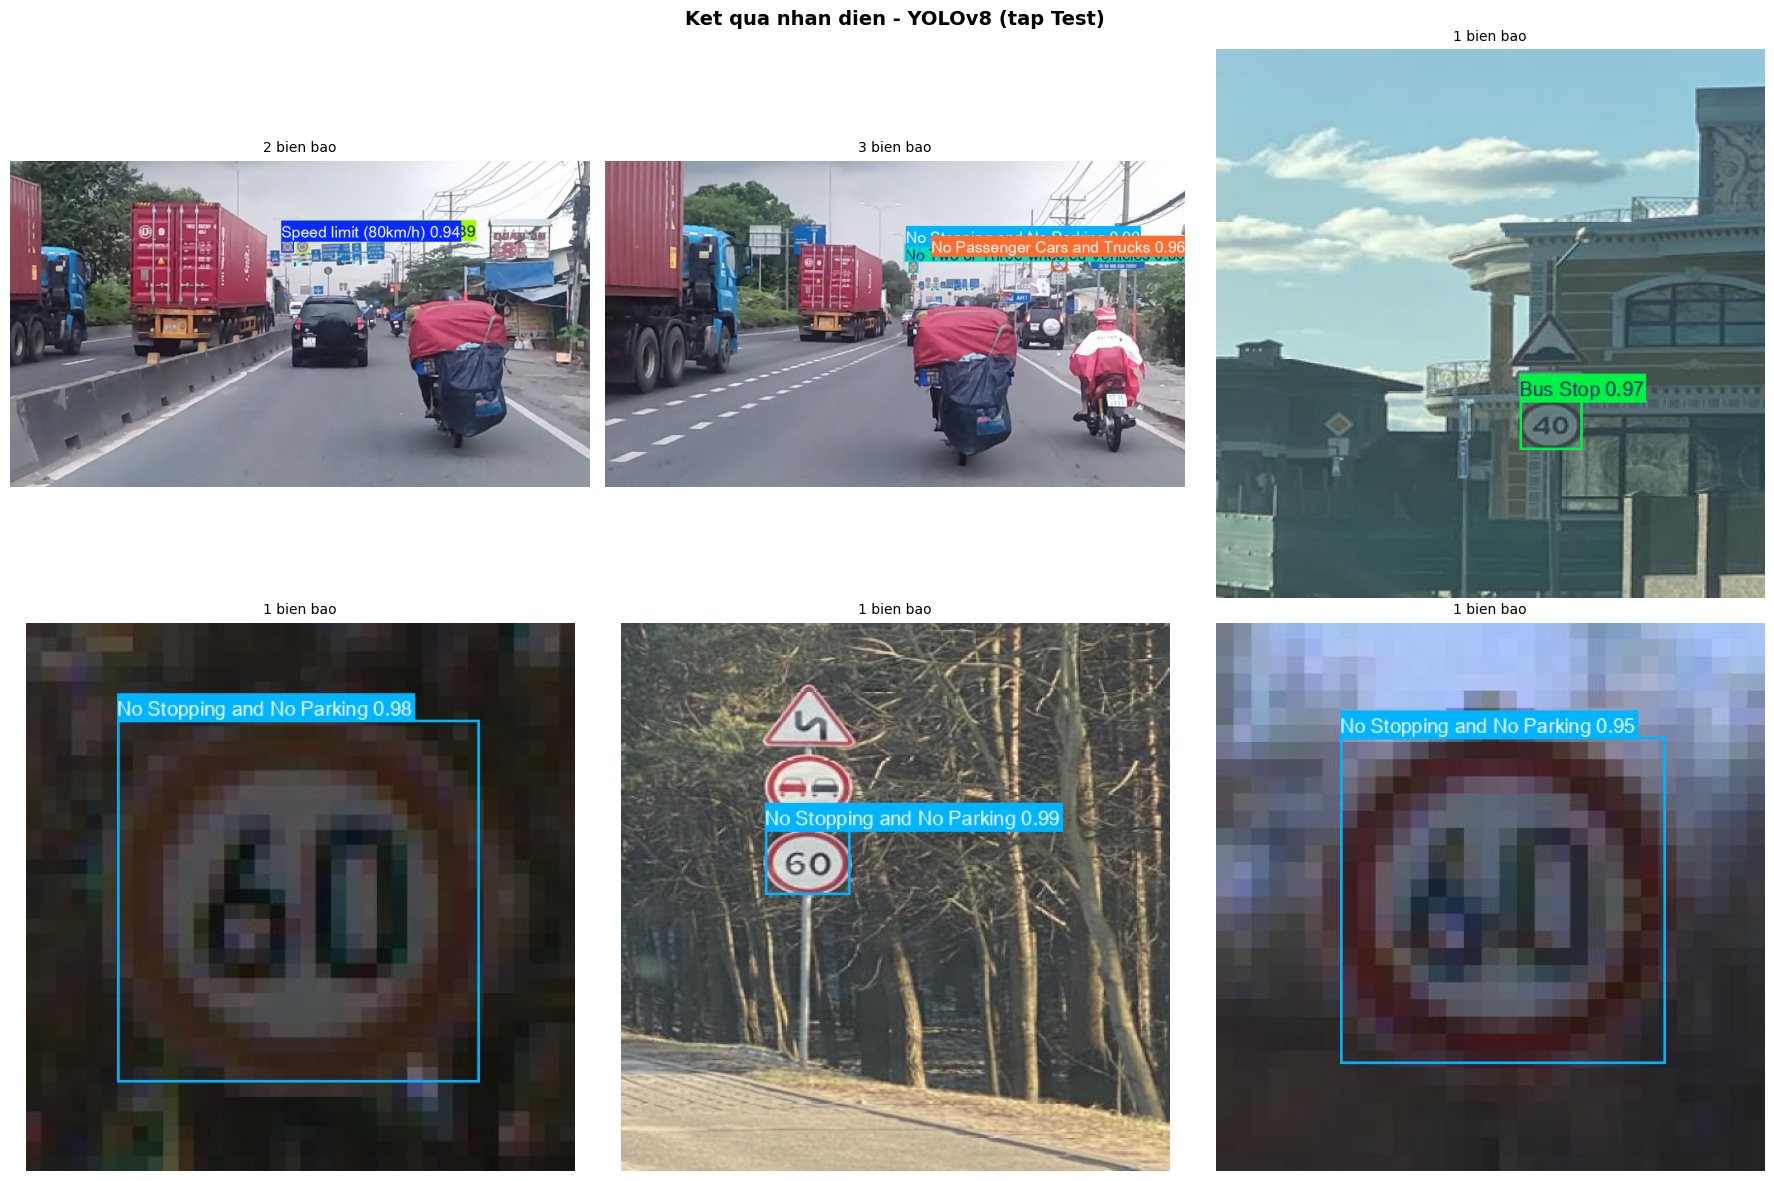

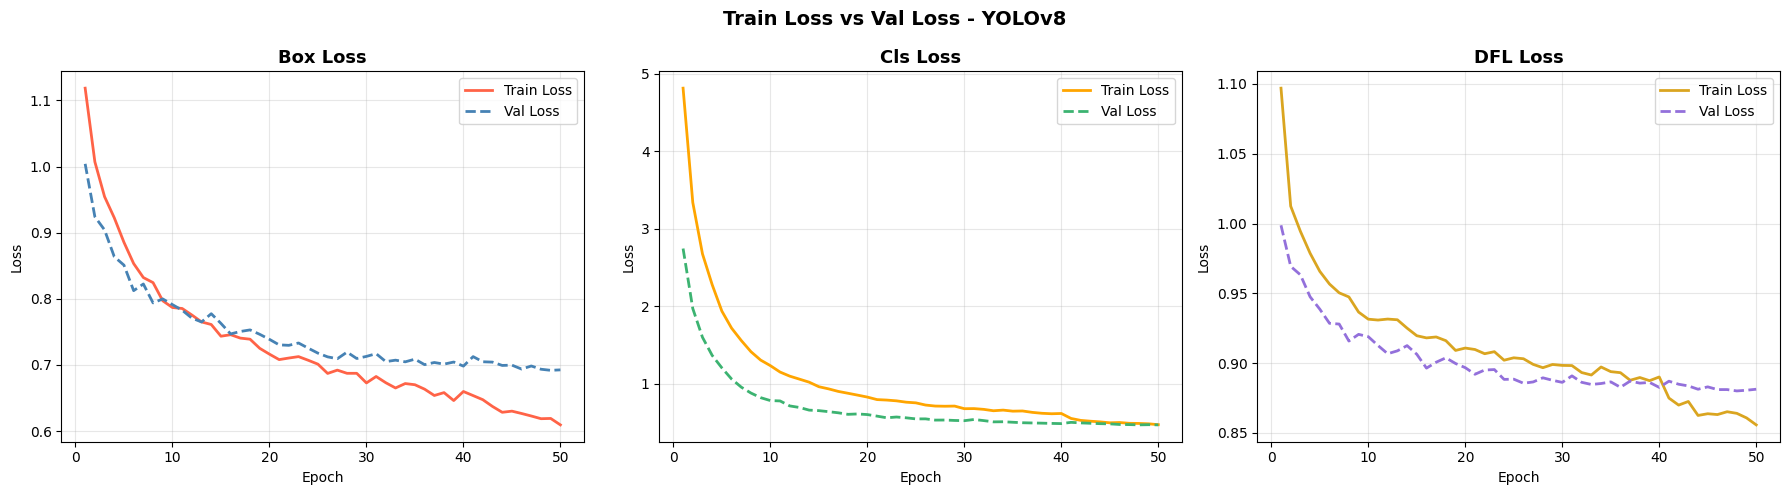

         TONG KET DU AN
  Model         : YOLOv8n
  Dataset       : 6746 anh / 67 class
  Train/Val/Test: 80% / 10% / 10%
  Epochs        : 50
  ── VAL ──
  mAP@50        : 94.8%
  mAP@50-95     : 74.4%
  ── TEST ──
  mAP@50        : 96.0%
  mAP@50-95     : 75.3%
  Precision     : 93.3%
  Recall        : 90.4%
  Model: /kaggle/working/doanai_yolov8/weights/best.pt


In [7]:
import cv2, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path

# ── 1. Predict ảnh test ──
test_imgs = list((WORK_DIR / 'test' / 'images').glob('*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(test_imgs):
    result = model_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_plot = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_plot)
    axes[i].set_title(f'{len(result.boxes)} bien bao', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Ket qua nhan dien - YOLOv8 (tap Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2. Train vs Val Loss ──
df = pd.read_csv('/kaggle/working/doanai_yolov8/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
loss_pairs = [
    ('train/box_loss', 'val/box_loss', 'Box Loss',  axes[0], 'tomato',    'steelblue'),
    ('train/cls_loss', 'val/cls_loss', 'Cls Loss',  axes[1], 'orange',    'mediumseagreen'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss',  axes[2], 'goldenrod', 'mediumpurple'),
]

for train_col, val_col, title, ax, c_train, c_val in loss_pairs:
    if train_col in df.columns and val_col in df.columns:
        ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2, label='Train Loss')
        ax.plot(df['epoch'], df[val_col],   color=c_val,   linewidth=2, label='Val Loss', linestyle='--')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Train Loss vs Val Loss - YOLOv8', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/train_val_loss.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 3. Tong ket ──
print('='*50)
print('         TONG KET DU AN')
print('='*50)
print(f'  Model         : YOLOv8n')
print(f'  Dataset       : 6746 anh / 67 class')
print(f'  Train/Val/Test: 80% / 10% / 10%')
print(f'  Epochs        : 50')
print(f'  ── VAL ──')
print(f'  mAP@50        : 94.8%')
print(f'  mAP@50-95     : 74.4%')
print(f'  ── TEST ──')
print(f'  mAP@50        : 96.0%')
print(f'  mAP@50-95     : 75.3%')
print(f'  Precision     : 93.3%')
print(f'  Recall        : 90.4%')
print('='*50)
print('  Model: /kaggle/working/doanai_yolov8/weights/best.pt')

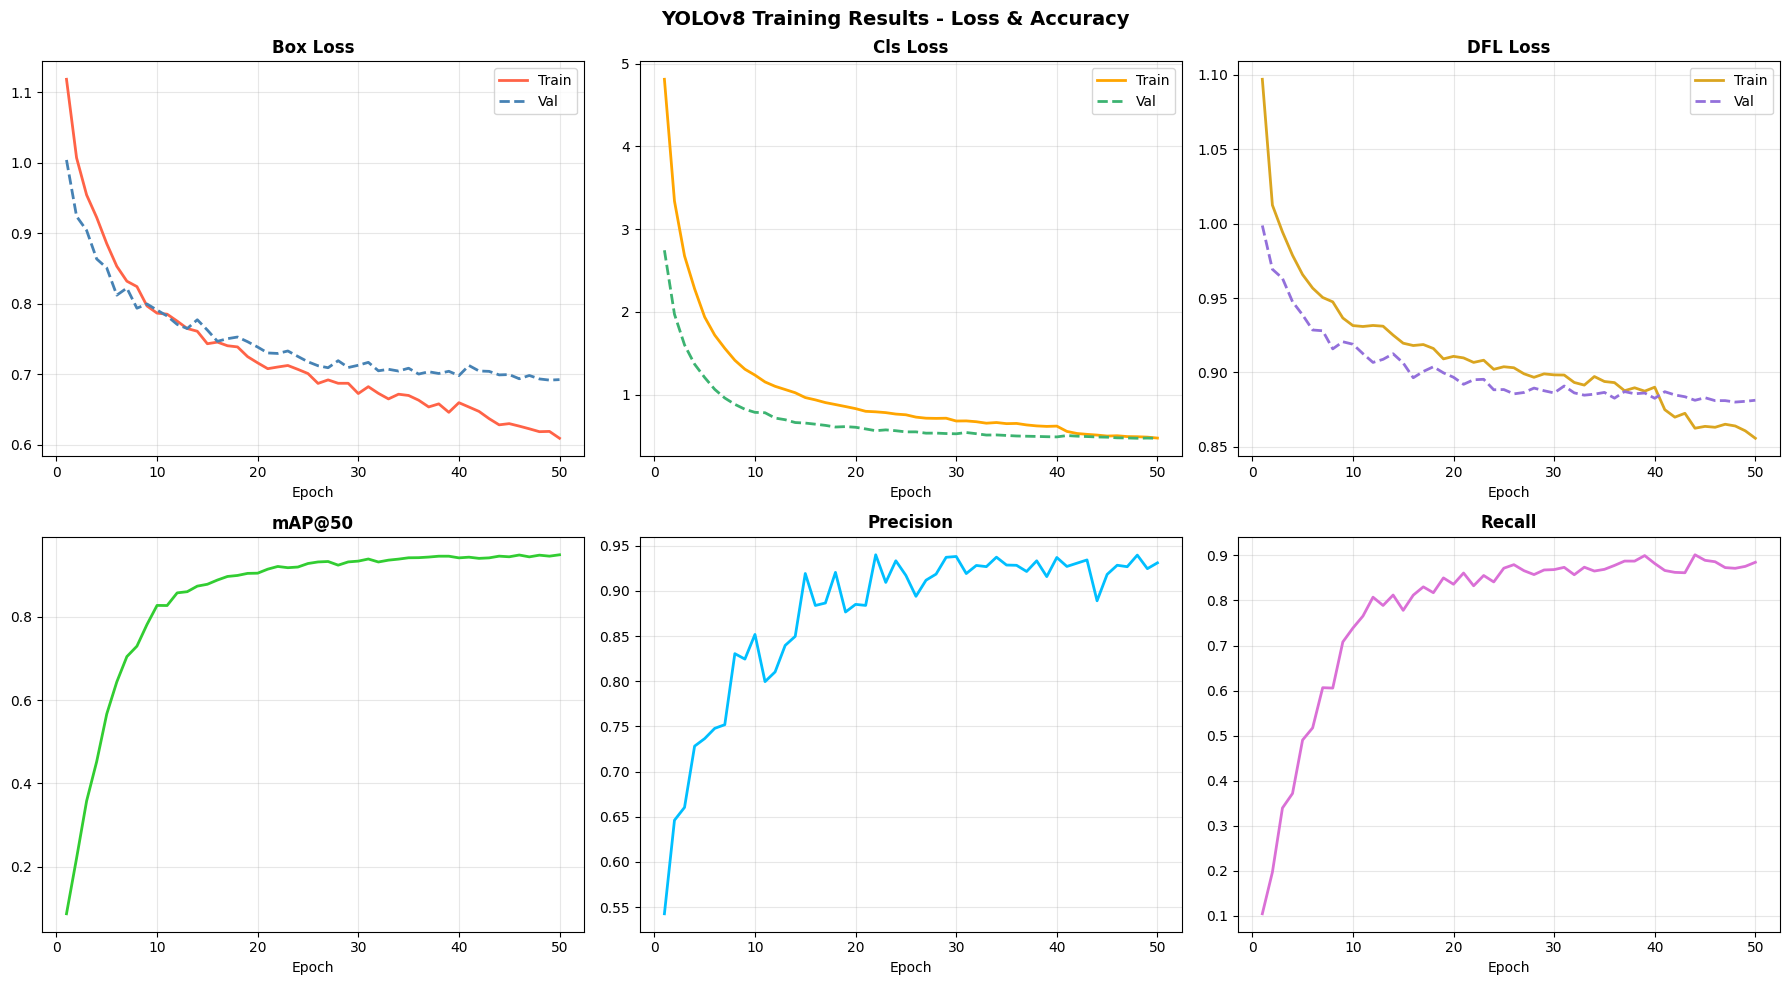

Done!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/working/doanai_yolov8/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    # Row 1: Loss
    ('train/box_loss', 'val/box_loss', 'Box Loss',  axes[0,0], 'tomato',    'steelblue'),
    ('train/cls_loss', 'val/cls_loss', 'Cls Loss',  axes[0,1], 'orange',    'mediumseagreen'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss',  axes[0,2], 'goldenrod', 'mediumpurple'),
    # Row 2: Accuracy
    ('metrics/mAP50(B)',     'metrics/mAP50(B)',     'mAP@50',    axes[1,0], 'limegreen',   'limegreen'),
    ('metrics/precision(B)', 'metrics/precision(B)', 'Precision', axes[1,1], 'deepskyblue', 'deepskyblue'),
    ('metrics/recall(B)',    'metrics/recall(B)',    'Recall',    axes[1,2], 'orchid',      'orchid'),
]

for train_col, val_col, title, ax, c_train, c_val in plots:
    if train_col in df.columns:
        if train_col == val_col:
            # Metrics: chỉ 1 đường
            ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2)
        else:
            # Loss: 2 đường train vs val
            ax.plot(df['epoch'], df[train_col], color=c_train, linewidth=2, label='Train')
            ax.plot(df['epoch'], df[val_col],   color=c_val,   linewidth=2, label='Val', linestyle='--')
            ax.legend()
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv8 Training Results - Loss & Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/full_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Done!')

In [9]:
from pathlib import Path
from collections import defaultdict

# Đọc tất cả label trong train/val/test
class_count = {split: defaultdict(int) for split in ['train', 'val', 'test']}

for split in ['train', 'val', 'test']:
    lbl_dir = WORK_DIR / split / 'labels'
    for lbl_file in lbl_dir.rglob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                class_count[split][cls_id] += 1

print(f'{"Class":<45} {"Train":>6} {"Val":>6} {"Test":>6}')
print('-' * 65)
for i, name in enumerate(classes):
    tr = class_count['train'].get(i, 0)
    va = class_count['val'].get(i, 0)
    te = class_count['test'].get(i, 0)
    flag = ' ⚠️' if va == 0 or te == 0 else ''
    print(f'{name:<45} {tr:>6} {va:>6} {te:>6}{flag}')

Class                                          Train    Val   Test
-----------------------------------------------------------------
Pedestrian Crossing                              674     89     91
Equal-level Intersection                         457     86     64
No Entry                                         404     46     39
Right Turn Only                                  589     67     65
Intersection                                     101     15     18
Intersection with a non-priority road            403     63     42
Danger zone on the left                          373     44     50
No Left Turn                                     467     65     49
Bus Stop                                         355     51     42
Roundabout                                       261     27     38
No Stopping and No Parking                      1065    150    157
U-Turn Allowed                                   278     22     44
Lane Allocation                                  474     63    